# HR Employee Attrition Analysis
**By:** Vipin Pandey
**Course:** MCA Data Science | UPES Dehradun
**Dataset:** IBM HR Analytics Employee Attrition (Kaggle)

In this project i analyzed 1470 employee records from IBM to understand why employees are leaving the company.
I used SQL for all the analysis and Python for visualization.

---

## 1. Setup

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('charts', exist_ok=True)

print('done')

done


## 2. Loading Data and Creating Database

In [2]:
df = pd.read_csv('hr_attrition.csv')
df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18'])

conn = sqlite3.connect('hr_database.db')
df.to_sql('hr_data', conn, if_exists='replace', index=False)

def run_query(sql):
    return pd.read_sql_query(sql, conn)

print('dataset loaded:', df.shape)
print('database ready')

dataset loaded: (1470, 32)
database ready


## 3. Overall Company Picture

In [3]:
q = """
SELECT
    COUNT(*) AS Total_Employees,
    SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) AS Left_Company,
    SUM(CASE WHEN Attrition='No' THEN 1 ELSE 0 END) AS Still_Working,
    ROUND(SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) AS Attrition_Rate,
    ROUND(AVG(Age),1) AS Avg_Age,
    ROUND(AVG(MonthlyIncome),0) AS Avg_Salary,
    ROUND(AVG(YearsAtCompany),1) AS Avg_Tenure
FROM hr_data
"""
run_query(q)

,Total_Employees,Left_Company,Still_Working,Attrition_Rate,Avg_Age,Avg_Salary,Avg_Tenure
0,1470,237,1233,16.12,36.9,6503.0,7.0


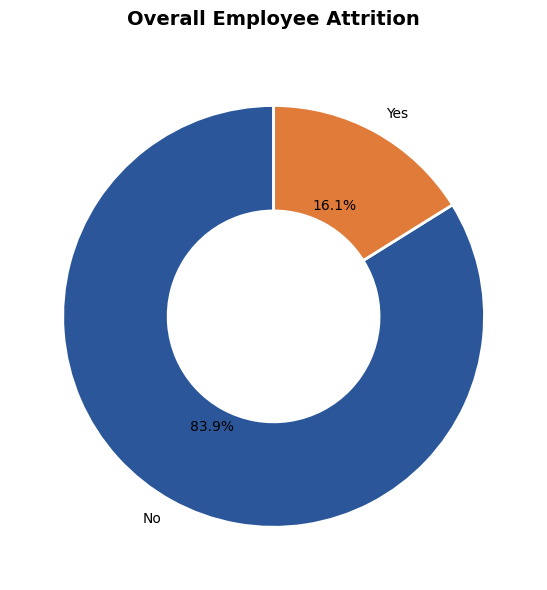

In [4]:
counts = run_query("SELECT Attrition, COUNT(*) AS Count FROM hr_data GROUP BY Attrition")

fig, ax = plt.subplots(figsize=(6,6))
ax.pie(counts['Count'], labels=counts['Attrition'], autopct='%1.1f%%',
       colors=['#2b579a','#e07b39'], startangle=90,
       wedgeprops=dict(width=0.5, edgecolor='white', linewidth=2))
ax.set_title('Overall Employee Attrition', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('charts/01_overall_attrition.png', dpi=150, bbox_inches='tight')
plt.show()

16.12% attrition means 1 in every 6 employees is leaving the company.

## 4. Department and Job Role Analysis

In [5]:
dept = run_query("""
SELECT Department, COUNT(*) AS Total,
SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) AS Left_Company,
ROUND(SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) AS Attrition_Rate
FROM hr_data GROUP BY Department ORDER BY Attrition_Rate DESC
""")
print(dept.to_string(index=False))

            Department  Total  Left_Company  Attrition_Rate
                 Sales    446            92           20.63
       Human Resources     63            12           19.05
Research & Development    961           133           13.84


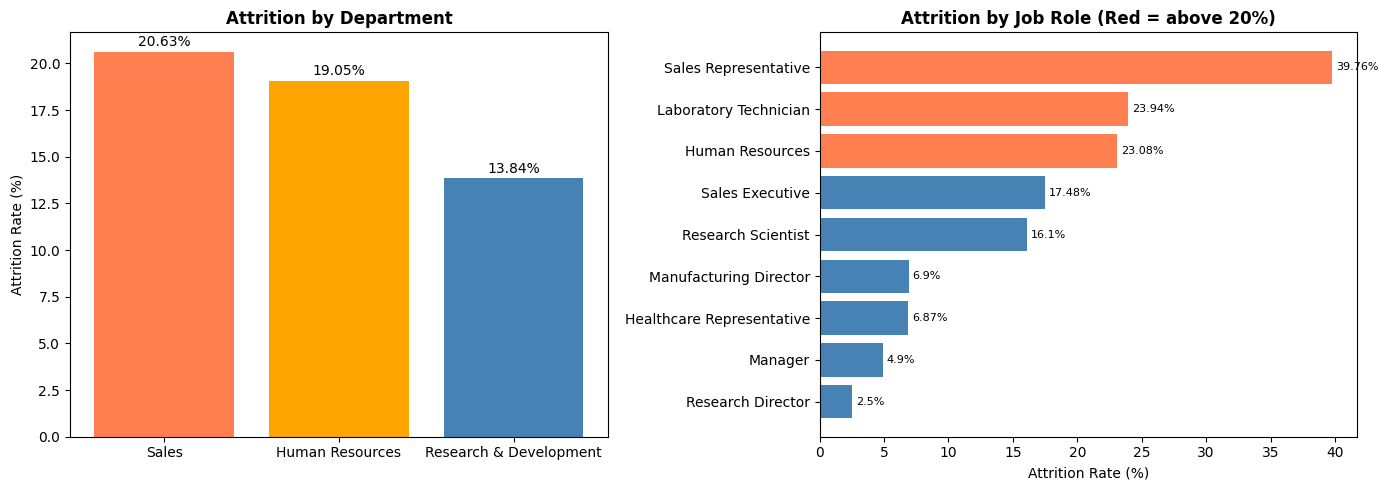

In [6]:
jobrole = run_query("""
SELECT JobRole,
ROUND(SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) AS Attrition_Rate
FROM hr_data GROUP BY JobRole ORDER BY Attrition_Rate
""")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(dept['Department'], dept['Attrition_Rate'],
            color=['coral','orange','steelblue'])
for bar, v in zip(axes[0].patches, dept['Attrition_Rate']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{v}%', ha='center', fontsize=10)
axes[0].set_title('Attrition by Department', fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')

colors = ['coral' if v > 20 else 'steelblue' for v in jobrole['Attrition_Rate']]
axes[1].barh(jobrole['JobRole'], jobrole['Attrition_Rate'], color=colors)
for i, v in enumerate(jobrole['Attrition_Rate']):
    axes[1].text(v+0.3, i, f'{v}%', va='center', fontsize=8)
axes[1].set_title('Attrition by Job Role (Red = above 20%)', fontweight='bold')
axes[1].set_xlabel('Attrition Rate (%)')

plt.tight_layout()
plt.savefig('charts/02_dept_jobrole.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Work Factor Analysis

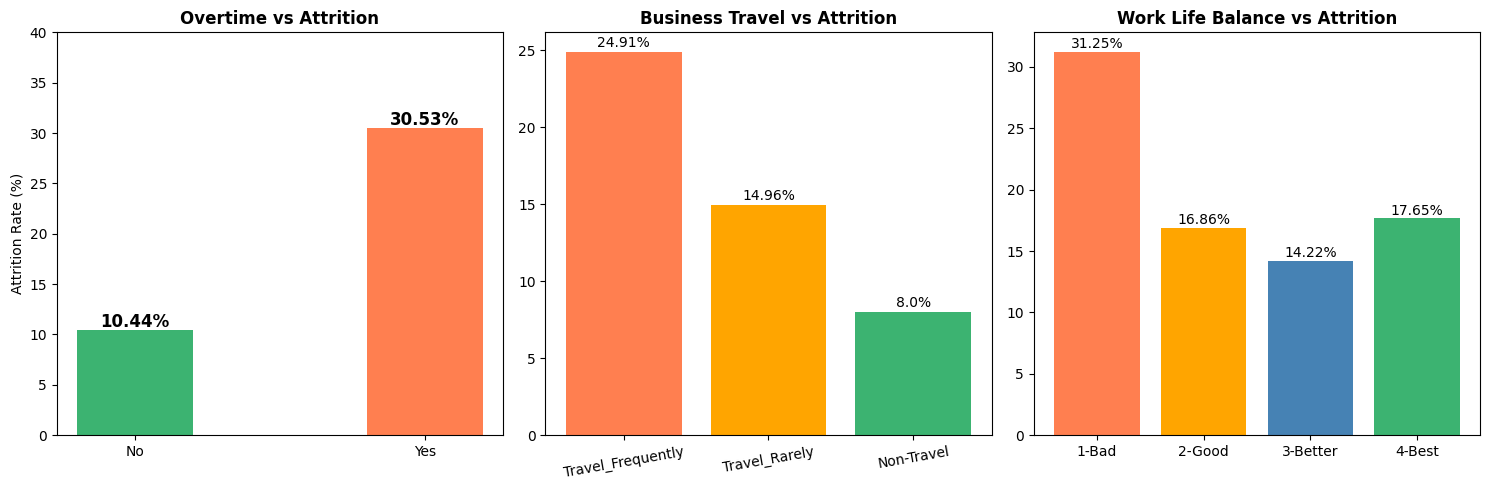

In [7]:
overtime = run_query("""
SELECT OverTime, COUNT(*) AS Total,
SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END) AS Left_Company,
ROUND(SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) AS Attrition_Rate
FROM hr_data GROUP BY OverTime
""")

travel = run_query("""
SELECT BusinessTravel,
ROUND(SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) AS Attrition_Rate
FROM hr_data GROUP BY BusinessTravel ORDER BY Attrition_Rate DESC
""")

wlb = run_query("""
SELECT WorkLifeBalance,
ROUND(SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) AS Attrition_Rate
FROM hr_data GROUP BY WorkLifeBalance ORDER BY WorkLifeBalance
""")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].bar(overtime['OverTime'], overtime['Attrition_Rate'],
            color=['mediumseagreen','coral'], width=0.4)
for bar, v in zip(axes[0].patches, overtime['Attrition_Rate']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{v}%', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Overtime vs Attrition', fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, 40)

axes[1].bar(travel['BusinessTravel'], travel['Attrition_Rate'],
            color=['coral','orange','mediumseagreen'])
for bar, v in zip(axes[1].patches, travel['Attrition_Rate']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{v}%', ha='center', fontsize=10)
axes[1].set_title('Business Travel vs Attrition', fontweight='bold')
axes[1].tick_params(axis='x', rotation=10)

wlb_labels = ['1-Bad','2-Good','3-Better','4-Best']
axes[2].bar(wlb_labels, wlb['Attrition_Rate'],
            color=['coral','orange','steelblue','mediumseagreen'])
for bar, v in zip(axes[2].patches, wlb['Attrition_Rate']):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{v}%', ha='center', fontsize=10)
axes[2].set_title('Work Life Balance vs Attrition', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/03_work_factors.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Demographics Analysis

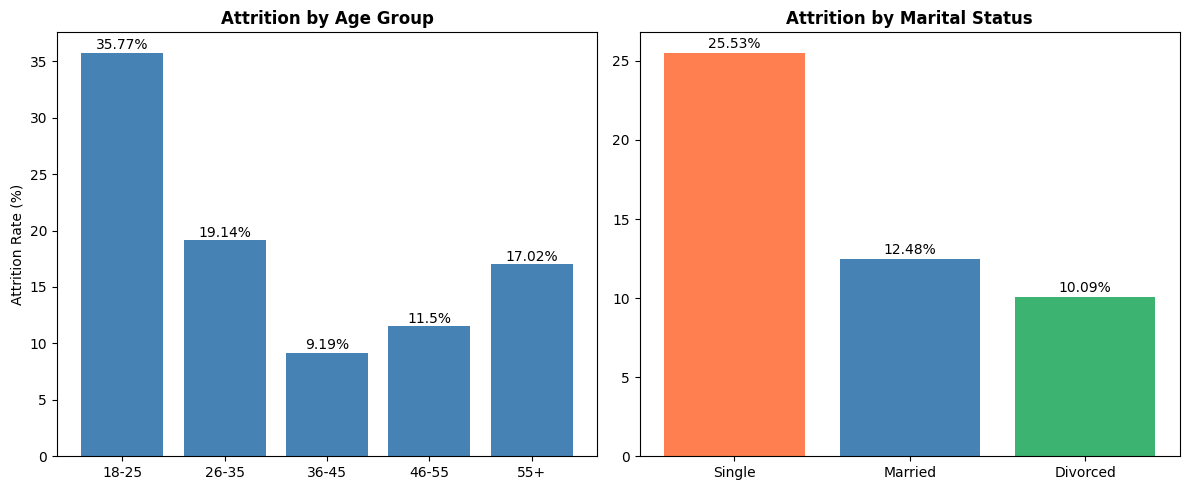

In [8]:
age_grp = run_query("""
SELECT
CASE WHEN Age BETWEEN 18 AND 25 THEN '18-25'
WHEN Age BETWEEN 26 AND 35 THEN '26-35'
WHEN Age BETWEEN 36 AND 45 THEN '36-45'
WHEN Age BETWEEN 46 AND 55 THEN '46-55'
ELSE '55+' END AS Age_Group,
ROUND(SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) AS Attrition_Rate
FROM hr_data GROUP BY Age_Group ORDER BY Age_Group
""")

marital = run_query("""
SELECT MaritalStatus,
ROUND(SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) AS Attrition_Rate
FROM hr_data GROUP BY MaritalStatus ORDER BY Attrition_Rate DESC
""")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(age_grp['Age_Group'], age_grp['Attrition_Rate'], color='steelblue')
for bar, v in zip(axes[0].patches, age_grp['Attrition_Rate']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{v}%', ha='center', fontsize=10)
axes[0].set_title('Attrition by Age Group', fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')

axes[1].bar(marital['MaritalStatus'], marital['Attrition_Rate'],
            color=['coral','steelblue','mediumseagreen'])
for bar, v in zip(axes[1].patches, marital['Attrition_Rate']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{v}%', ha='center', fontsize=10)
axes[1].set_title('Attrition by Marital Status', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/04_demographics.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Salary Analysis

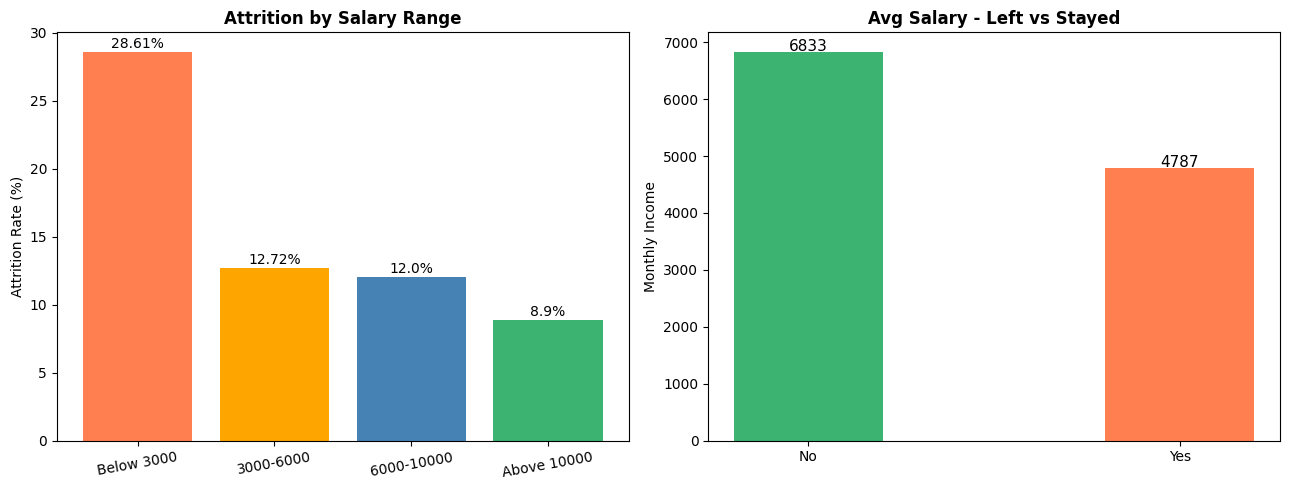

In [9]:
salary = run_query("""
SELECT
CASE WHEN MonthlyIncome < 3000 THEN 'Below 3000'
WHEN MonthlyIncome BETWEEN 3000 AND 6000 THEN '3000-6000'
WHEN MonthlyIncome BETWEEN 6001 AND 10000 THEN '6000-10000'
ELSE 'Above 10000' END AS Salary_Range,
ROUND(SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) AS Attrition_Rate
FROM hr_data GROUP BY Salary_Range ORDER BY Attrition_Rate DESC
""")

avg_sal = run_query("""
SELECT Attrition, ROUND(AVG(MonthlyIncome),0) AS Avg_Salary
FROM hr_data GROUP BY Attrition
""")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(salary['Salary_Range'], salary['Attrition_Rate'],
            color=['coral','orange','steelblue','mediumseagreen'])
for bar, v in zip(axes[0].patches, salary['Attrition_Rate']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{v}%', ha='center', fontsize=10)
axes[0].set_title('Attrition by Salary Range', fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].tick_params(axis='x', rotation=10)

axes[1].bar(avg_sal['Attrition'], avg_sal['Avg_Salary'],
            color=['mediumseagreen','coral'], width=0.4)
for bar, v in zip(axes[1].patches, avg_sal['Avg_Salary']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 f'{int(v)}', ha='center', fontsize=11)
axes[1].set_title('Avg Salary - Left vs Stayed', fontweight='bold')
axes[1].set_ylabel('Monthly Income')

plt.tight_layout()
plt.savefig('charts/05_salary_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Attrition Heatmap

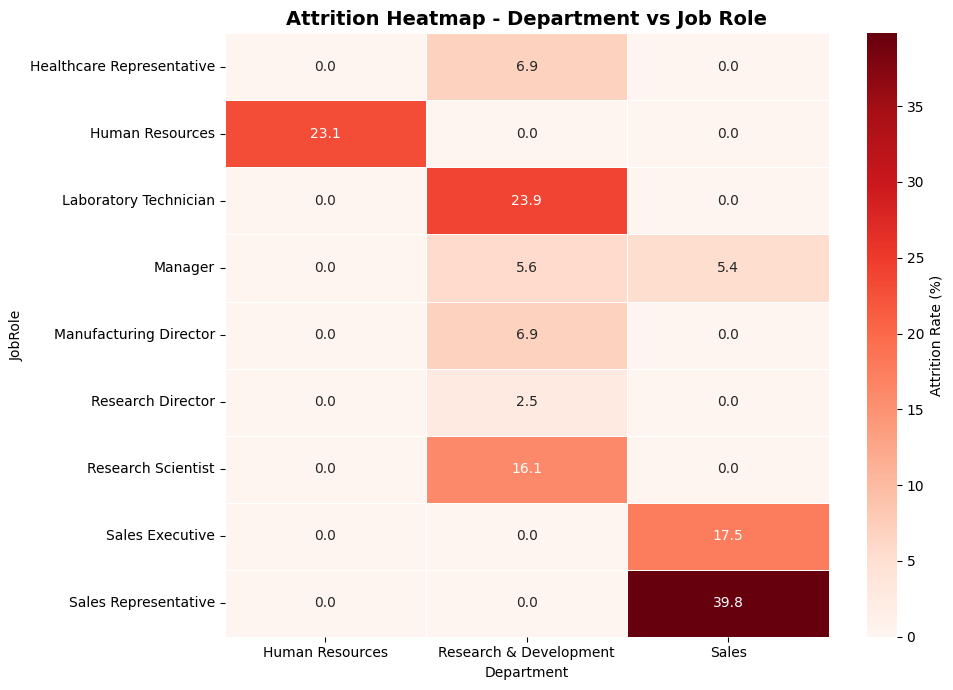

In [10]:
heatmap_data = run_query("""
SELECT Department, JobRole,
ROUND(SUM(CASE WHEN Attrition='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),1) AS Attrition_Rate
FROM hr_data GROUP BY Department, JobRole
""")

pivot = heatmap_data.pivot(index='JobRole', columns='Department', values='Attrition_Rate').fillna(0)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='Reds', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Attrition Rate (%)'})
ax.set_title('Attrition Heatmap - Department vs Job Role', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/06_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Employee Risk Scoring

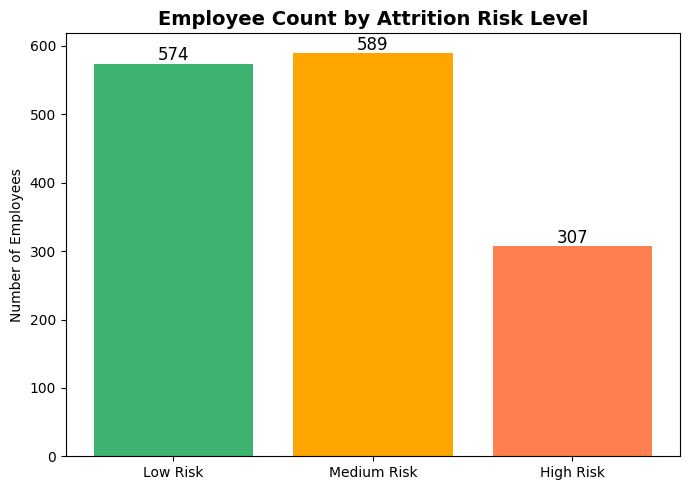

Attrition    Yes   No  Actual_Attrition_Rate
Risk_Level                                  
Low Risk      29  545                    5.1
Medium Risk   73  516                   12.4
High Risk    135  172                   44.0


In [11]:
df_full = pd.read_sql_query('SELECT * FROM hr_data', conn)

df_full['Risk_Score'] = 0
df_full.loc[df_full['OverTime']=='Yes', 'Risk_Score'] += 3
df_full.loc[df_full['MaritalStatus']=='Single', 'Risk_Score'] += 2
df_full.loc[df_full['BusinessTravel']=='Travel_Frequently', 'Risk_Score'] += 2
df_full.loc[df_full['JobSatisfaction']<=2, 'Risk_Score'] += 2
df_full.loc[df_full['WorkLifeBalance']==1, 'Risk_Score'] += 2
df_full.loc[df_full['MonthlyIncome']<3000, 'Risk_Score'] += 2
df_full.loc[df_full['YearsAtCompany']<=2, 'Risk_Score'] += 1
df_full.loc[df_full['Age']<=25, 'Risk_Score'] += 1

df_full['Risk_Level'] = pd.cut(df_full['Risk_Score'], bins=[-1,2,5,100],
                               labels=['Low Risk','Medium Risk','High Risk'])

risk_counts = df_full['Risk_Level'].value_counts().reset_index()
risk_counts.columns = ['Risk_Level','Count']
order = ['Low Risk','Medium Risk','High Risk']
risk_counts['Risk_Level'] = pd.Categorical(risk_counts['Risk_Level'], categories=order, ordered=True)
risk_counts = risk_counts.sort_values('Risk_Level')

fig, ax = plt.subplots(figsize=(7,5))
ax.bar(risk_counts['Risk_Level'], risk_counts['Count'],
       color=['mediumseagreen','orange','coral'])
for bar, v in zip(ax.patches, risk_counts['Count']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
            str(v), ha='center', fontsize=12)
ax.set_title('Employee Count by Attrition Risk Level', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Employees')
plt.tight_layout()
plt.savefig('charts/07_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

validation = df_full.groupby(['Risk_Level','Attrition']).size().unstack(fill_value=0)
validation['Actual_Attrition_Rate'] = round(validation['Yes']/(validation['Yes']+validation['No'])*100,1)
print(validation[['Yes','No','Actual_Attrition_Rate']])

## 10. Key Findings and Recommendations

In [12]:
print('='*55)
print('KEY FINDINGS')
print('='*55)
findings = [
    ('Sales Representative', 39.76, 'Job Role'),
    ('Age Group 18-25', 37.84, 'Demographics'),
    ('Overtime = Yes', 30.53, 'Work Factor'),
    ('Work Life Balance = 1', 31.25, 'Work Factor'),
    ('Tenure 0-2 Years', 31.25, 'Experience'),
    ('Below 3000 Salary', 29.81, 'Compensation'),
    ('Single Employees', 25.53, 'Personal'),
    ('Frequent Travelers', 24.91, 'Work Factor'),
    ('Sales Department', 20.63, 'Department'),
    ('Low Job Satisfaction', 22.84, 'Satisfaction'),
]
for name, rate, category in sorted(findings, key=lambda x: x[1], reverse=True):
    print(f'{name:<35} {rate:>5}%  [{category}]')
print('='*55)

KEY FINDINGS
Sales Representative                39.76%  [Job Role]
Age Group 18-25                     37.84%  [Demographics]
Work Life Balance = 1               31.25%  [Work Factor]
Tenure 0-2 Years                    31.25%  [Experience]
Overtime = Yes                      30.53%  [Work Factor]
Below 3000 Salary                   29.81%  [Compensation]
Single Employees                    25.53%  [Personal]
Frequent Travelers                  24.91%  [Work Factor]
Low Job Satisfaction                22.84%  [Satisfaction]
Sales Department                    20.63%  [Department]


In [13]:
print()
print('RECOMMENDATIONS FOR MANAGEMENT')
print('-'*55)
recommendations = [
    '1. Review overtime policy — 30% of overtime employees are leaving',
    '2. Focus on Sales department — highest attrition rate at 20.63%',
    '3. Create retention programs for employees in first 2 years',
    '4. Improve salary structure for employees below 3000 income',
    '5. Reduce frequent business travel or add travel benefits',
    '6. Regular work life balance check-ins especially for young employees',
]
for r in recommendations:
    print(r)


RECOMMENDATIONS FOR MANAGEMENT
-------------------------------------------------------
1. Review overtime policy — 30% of overtime employees are leaving
2. Focus on Sales department — highest attrition rate at 20.63%
3. Create retention programs for employees in first 2 years
4. Improve salary structure for employees below 3000 income
5. Reduce frequent business travel or add travel benefits
6. Regular work life balance check-ins especially for young employees


In [14]:
conn.close()
print()
print('Analysis complete!')
print('Total charts saved:', len(os.listdir('charts')))
print('GitHub repo ready to push')


Analysis complete!
Total charts saved: 19
GitHub repo ready to push


---
## Summary

I analyzed 1470 IBM employee records using SQL and Python to understand why employees are leaving.

The overall attrition rate is 16.12% which means 1 in 6 employees is leaving the company.

The biggest risk factors are overtime work, young age, low salary, poor work life balance, and being in the Sales department. Employees who work overtime are 3 times more likely to leave compared to those who do not.

Based on the risk scoring model, the company can identify high risk employees early and take preventive action before they decide to leave.

**Tools used:** Python, SQLite, Pandas, Matplotlib, Seaborn, Jupyter Notebook, Power BI